In [28]:
import sys
!{sys.executable} -m pip install xlrd>=2.0.1

import pandas as pd

df = pd.read_excel(
    "default of credit card clients.xls",
    header=1  # Neccessary for UCI file
)

X = df.iloc[:, 1:-1]  # ID hariç, target hariç
y = df.iloc[:, -1]    # default payment


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # sınıf dengesini korur
)


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,        # ağaç sayısı
    max_depth=None,          # otomatik derinlik
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced", # sınıf dengesizliği için önemli
    random_state=42,
    n_jobs=-1                # tüm çekirdekleri kullan
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       min_samples_split=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [31]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7991666666666667
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4673
           1       0.55      0.52      0.53      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.70      0.70      6000
weighted avg       0.80      0.80      0.80      6000



In [32]:
y_proba = rf.predict_proba(X_test)[:, 1]  # default olma olasılığı


In [33]:
import pandas as pd

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.head(10))


PAY_0        0.141906
BILL_AMT1    0.056268
LIMIT_BAL    0.055857
PAY_2        0.054428
PAY_AMT1     0.051486
PAY_AMT2     0.051404
BILL_AMT2    0.049140
PAY_AMT3     0.048219
BILL_AMT3    0.045813
AGE          0.044965
dtype: float64


In [34]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", auc)


ROC-AUC: 0.7696241504088568


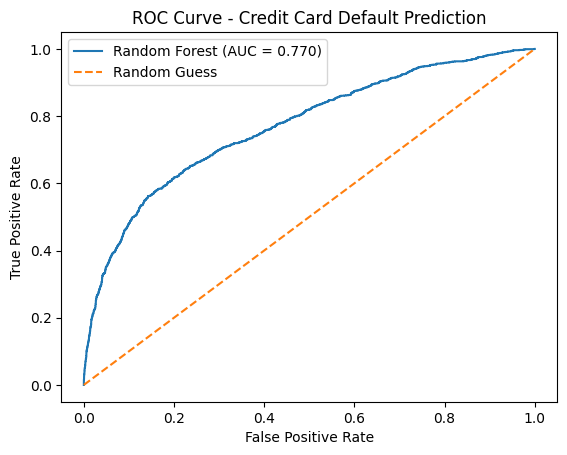

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
plt.figure()
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Card Default Prediction")
plt.legend()
plt.show()


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_base = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


RandomizedSearchCV(cv=5,
                   estimator=RandomForestClassifier(class_weight='balanced',
                                                    n_jobs=-1,
                                                    random_state=42),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 3, 5],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [37]:
print("Best AUC (Randomized):", random_search.best_score_)
print("Best Params:", random_search.best_params_)


Best AUC (Randomized): 0.7816461005335338
Best Params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 30}


In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [250, 300, 350],
    "max_depth": [15, 20, 25],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 3, 4],
    "max_features": ["sqrt"]
}


In [39]:
grid_search = GridSearchCV(
    rf_base,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [15, 20, 25], 'max_features': ['sqrt'],
                         'min_samples_leaf': [2, 3, 4],
                         'min_samples_split': [5, 10],
                         'n_estimators': [250, 300, 350]},
             scoring='roc_auc', verbose=2)

In [48]:
best_rf = random_search.best_estimator_

print("Best AUC (Grid):", grid_search.best_score_)
print("Best Params:", grid_search.best_params_)


Best AUC (Grid): 0.7813068579427218
Best Params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 350}


In [41]:
y_proba = best_rf.predict_proba(X_test)[:, 1]


In [42]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred_t, average="binary"
    )
    results.append((t, precision, recall, f1))

for r in results:
    print(f"Threshold={r[0]:.2f} | Precision={r[1]:.3f} | Recall={r[2]:.3f} | F1={r[3]:.3f}")


Threshold=0.10 | Precision=0.239 | Recall=0.978 | F1=0.384
Threshold=0.15 | Precision=0.266 | Recall=0.939 | F1=0.415
Threshold=0.20 | Precision=0.298 | Recall=0.864 | F1=0.443
Threshold=0.25 | Precision=0.345 | Recall=0.778 | F1=0.478
Threshold=0.30 | Precision=0.398 | Recall=0.702 | F1=0.508
Threshold=0.35 | Precision=0.446 | Recall=0.629 | F1=0.522
Threshold=0.40 | Precision=0.496 | Recall=0.590 | F1=0.539
Threshold=0.45 | Precision=0.532 | Recall=0.547 | F1=0.540
Threshold=0.50 | Precision=0.564 | Recall=0.512 | F1=0.537
Threshold=0.55 | Precision=0.581 | Recall=0.466 | F1=0.517
Threshold=0.60 | Precision=0.608 | Recall=0.414 | F1=0.493
Threshold=0.65 | Precision=0.656 | Recall=0.365 | F1=0.470
Threshold=0.70 | Precision=0.697 | Recall=0.307 | F1=0.426
Threshold=0.75 | Precision=0.723 | Recall=0.244 | F1=0.365
Threshold=0.80 | Precision=0.748 | Recall=0.175 | F1=0.283
Threshold=0.85 | Precision=0.825 | Recall=0.106 | F1=0.188


In [43]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

print("Average Precision:", ap_score)


Average Precision: 0.5491428091054771


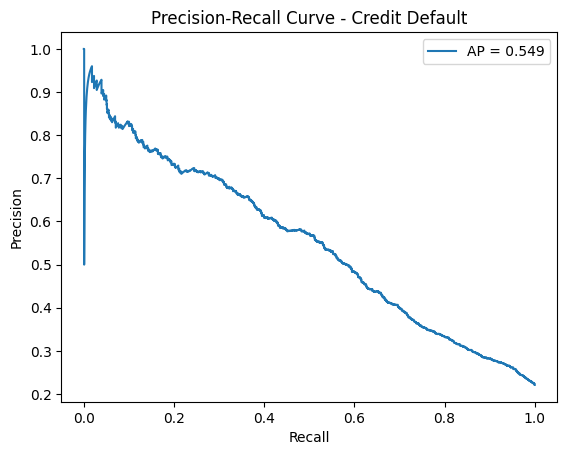

In [44]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Credit Default")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = best_rf.predict(X_test)  # default threshold = 0.50

cm = confusion_matrix(y_test, y_pred)


# custom threshold=0.30
cm_new =confusion_matrix(y_test, (best_rf.predict_proba(X_test)[:,1] >= 0.30).astype(int))

print(cm)
print(cm_new)


[[4126  547]
 [ 639  688]]
[[3227 1446]
 [ 402  925]]


<Figure size 640x480 with 0 Axes>

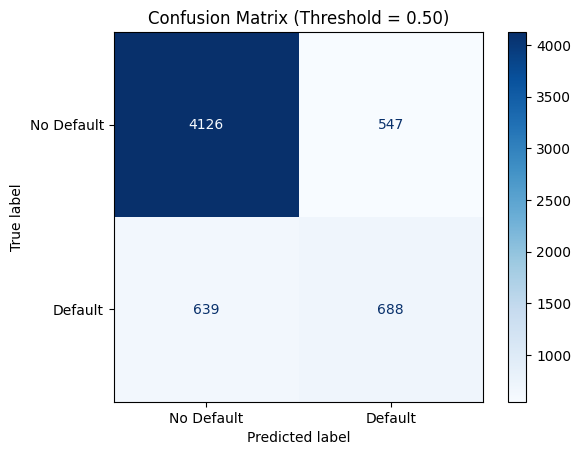

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

plt.figure()
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Default", "Default"]
).plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix (Threshold = 0.50)")
plt.show()

<Figure size 640x480 with 0 Axes>

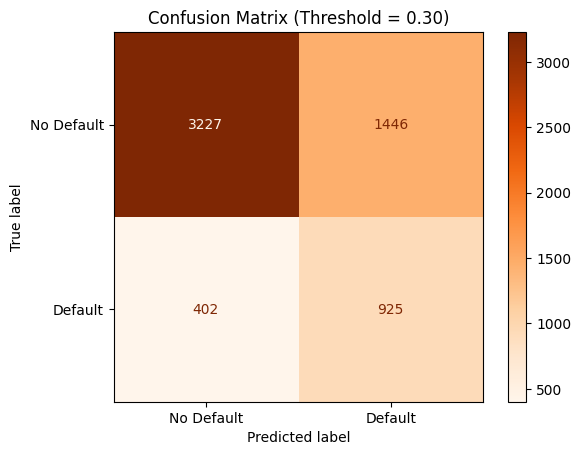

In [51]:
plt.figure()
ConfusionMatrixDisplay(
    confusion_matrix=cm_new,
    display_labels=["No Default", "Default"]
).plot(cmap="Oranges", values_format="d")

plt.title("Confusion Matrix (Threshold = 0.30)")
plt.show()